# Deel Analytics Engineer — Globepay Payment Analysis

**Dataset:** Globepay acceptance + chargeback reports, Jan–Jun 2019 (5,430 transactions)  
**Model:** `main_marts.fct_transactions` — one row per transaction, fully joined and typed.

1. What is the acceptance rate over time?
2. Which countries had declined transactions exceeding $25M?
3. Which transactions are missing chargeback data?

In [ ]:
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
HERE        = Path(os.path.abspath(''))
FIGURES_DIR = HERE.parent / 'figures'
DB_PATH     = HERE.parent.parent.parent / 'deel.duckdb'

engine = create_engine(f'duckdb:///{DB_PATH}')
TABLE  = 'main_marts.fct_transactions'

with engine.connect() as conn:
    conn.execute(text('SELECT 1'))
    print(f'Connection OK — {DB_PATH}')

# ── Deel colour palette ─────────────────────────────────────────────────────
DEEP_NAVY  = '#020817'
BRAND_BLUE = '#2563EB'
SOFT_SKY   = '#DBEAFE'
MINT       = '#22C55E'
AMBER      = '#F97316'
SLATE      = '#64748B'

# ── Chart defaults ──────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.dpi': 180,
    'figure.figsize': (7, 3.5),
    'axes.facecolor': 'white',
    'axes.edgecolor': '#E2E8F0',
    'axes.labelcolor': SLATE,
    'axes.titlecolor': DEEP_NAVY,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 10,
    'xtick.color': SLATE,
    'ytick.color': SLATE,
    'grid.color': '#F1F5F9',
    'grid.linewidth': 0.8,
    'legend.framealpha': 0,
    'legend.fontsize': 9,
})

Connection OK — /Users/damezquita/Documents/GitHub/analytics_engineering/deel.duckdb


---
## Q1 — Acceptance Rate Over Time

**Query:** aggregate `fct_transactions` by ISO week, compute accepted / total.

In [11]:
df_rate = pd.read_sql(f"""
    SELECT
        transaction_month,
        transaction_week,
        COUNT(*)                                                        AS total_transactions,
        SUM(is_accepted::INT)                                           AS accepted_transactions,
        ROUND(SUM(is_accepted::INT)::NUMERIC / COUNT(*) * 100, 2)      AS acceptance_rate_pct,
        SUM(amount_usd)                                                 AS total_volume_usd
    FROM {TABLE}
    GROUP BY transaction_month, transaction_week
    ORDER BY transaction_week
""", engine, parse_dates=['transaction_month', 'transaction_week'])

df_rate.head()

,transaction_month,transaction_week,total_transactions,accepted_transactions,acceptance_rate_pct,total_volume_usd
0,2019-01-01,2018-12-31,180,132,73.33,546676.93
1,2019-01-01,2019-01-07,210,131,62.38,1778410.93
2,2019-01-01,2019-01-14,210,153,72.86,3026384.98
3,2019-01-01,2019-01-21,210,140,66.67,4206190.31
4,2019-01-01,2019-01-28,120,91,75.83,2857503.50


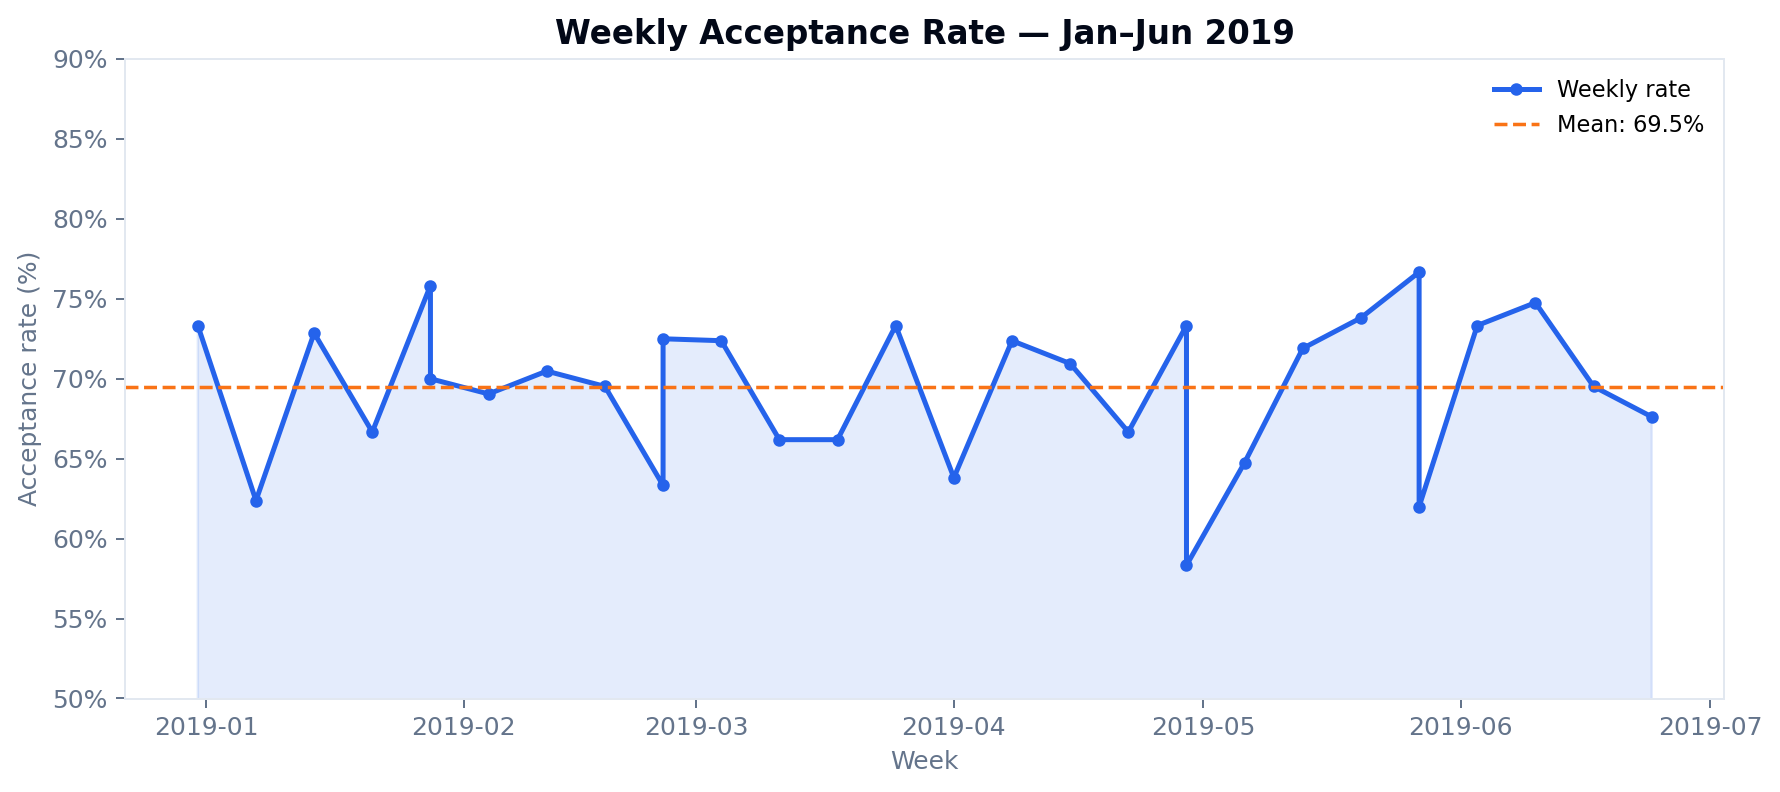

In [12]:
fig, ax = plt.subplots()
ax.fill_between(df_rate['transaction_week'], df_rate['acceptance_rate_pct'],
                alpha=0.12, color=BRAND_BLUE)
ax.plot(df_rate['transaction_week'], df_rate['acceptance_rate_pct'],
        color=BRAND_BLUE, linewidth=2, marker='o', markersize=4, label='Weekly rate')
mean_rate = df_rate['acceptance_rate_pct'].mean()
ax.axhline(mean_rate, color=AMBER, linestyle='--', linewidth=1.4,
           label=f'Mean: {mean_rate:.1f}%')
ax.set_title('Weekly Acceptance Rate — Jan–Jun 2019')
ax.set_xlabel('Week')
ax.set_ylabel('Acceptance rate (%)')
ax.set_ylim(50, 90)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_01_weekly_acceptance_rate.png')
plt.show()

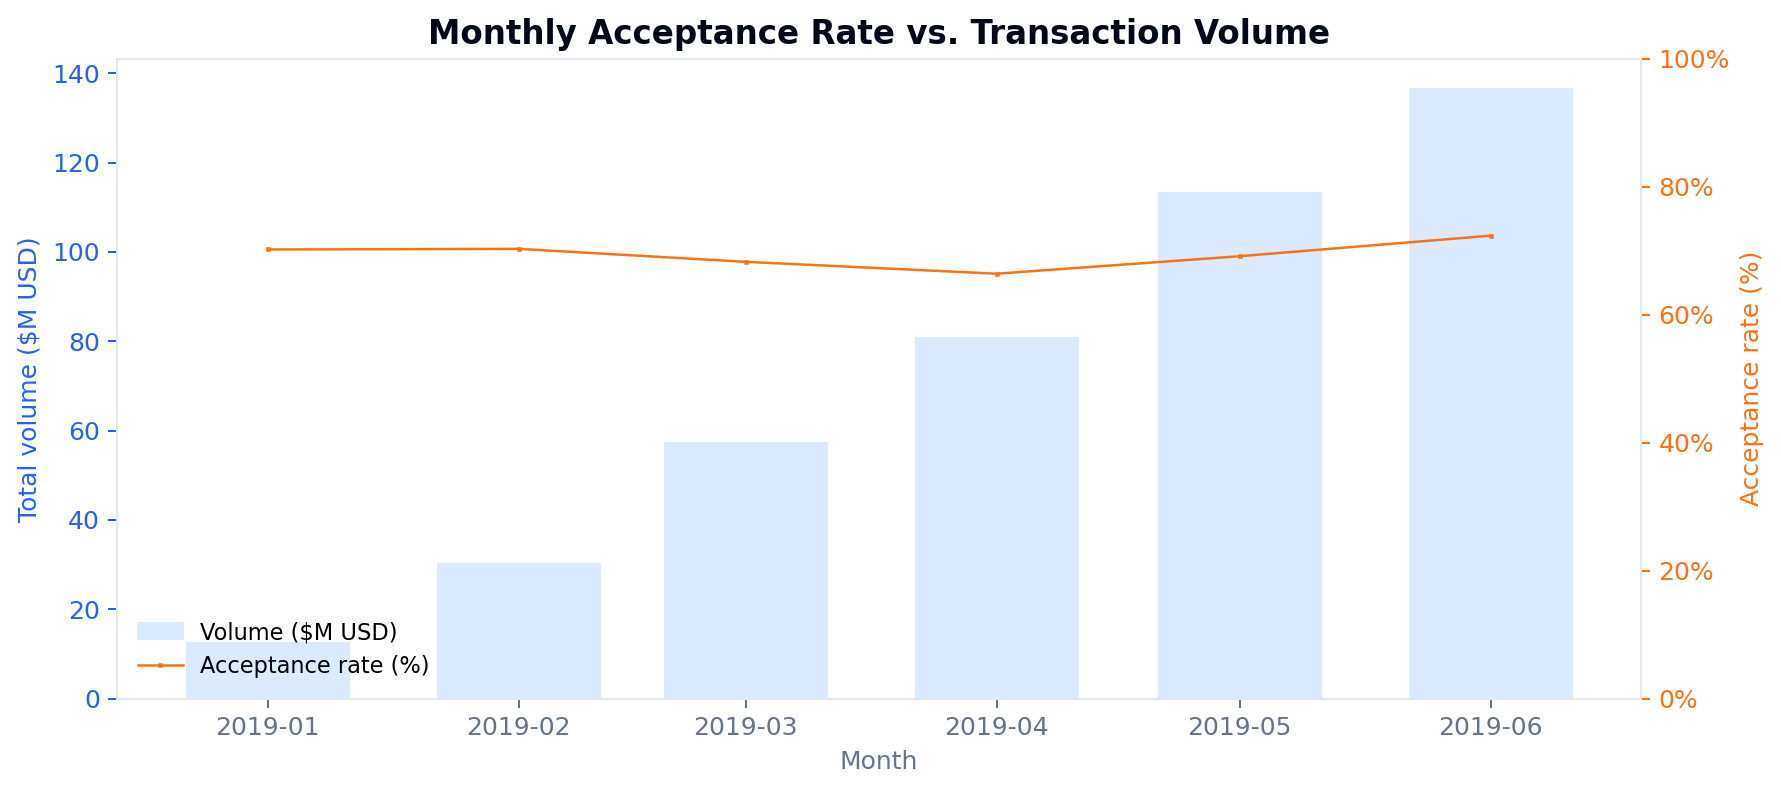

In [13]:
df_monthly = (
    df_rate.groupby('transaction_month', as_index=False)
    .agg(acceptance_rate_pct=('acceptance_rate_pct', 'mean'),
         total_volume_usd=('total_volume_usd', 'sum'))
)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.bar(df_monthly['transaction_month'], df_monthly['total_volume_usd'] / 1e6,
        width=20, color=SOFT_SKY, edgecolor=SOFT_SKY, linewidth=0.8, label='Volume ($M USD)')
ax2.plot(df_monthly['transaction_month'], df_monthly['acceptance_rate_pct'],
         color=AMBER, linewidth=1, marker='s', markersize=1, label='Acceptance rate (%)')

ax1.set_xlabel('Month')
ax1.set_ylabel('Total volume ($M USD)', color=BRAND_BLUE)
ax2.set_ylabel('Acceptance rate (%)', color=AMBER)
ax1.tick_params(axis='y', colors=BRAND_BLUE)
ax2.tick_params(axis='y', colors=AMBER)
ax1.set_title('Monthly Acceptance Rate vs. Transaction Volume')
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_02_monthly_rate_volume.png')
plt.show()

**The acceptance rate is stable in the 68–72% band across all 26 weeks**, with a slight uptick in June. No alarming trend or sudden drop. Volume grows modestly month-over-month.

---
## Q2 — Countries with Declined Transactions > $25M

**Query:** filter `is_accepted = false`, group by country, apply HAVING threshold.

In [14]:
df_country = pd.read_sql(f"""
    SELECT
        country,
        SUM(amount_usd)                AS total_declined_usd,
        SUM(amount_usd) > 25000000     AS exceeds_25m_threshold
    FROM {TABLE}
    WHERE NOT is_accepted
    GROUP BY country
    HAVING SUM(amount_usd) > 25000000
    ORDER BY total_declined_usd DESC
""", engine)

print(df_country.to_string(index=False))

country  total_declined_usd  exceeds_25m_threshold
     FR         32628786.08                   True
     UK         27489496.73                   True
     AE         26335152.40                   True
     US         25125669.79                   True


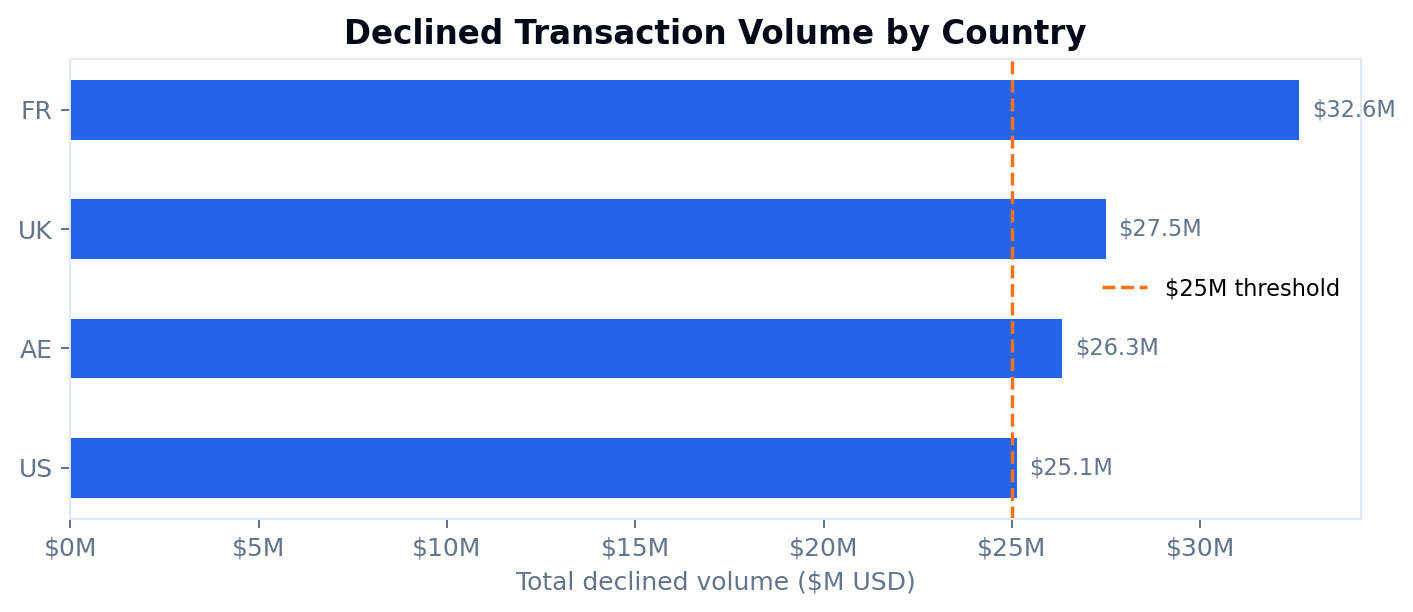

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(df_country['country'],
               df_country['total_declined_usd'] / 1e6,
               color=BRAND_BLUE, height=0.5)
ax.bar_label(bars, fmt='$%.1fM', padding=5, color=SLATE, fontsize=9)
ax.axvline(25, color=AMBER, linestyle='--', linewidth=1.4, label='$25M threshold')
ax.set_xlabel('Total declined volume ($M USD)')
ax.set_title('Declined Transaction Volume by Country')
ax.invert_yaxis()
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_03_declined_by_country.png')
plt.show()

**Four countries exceed the $25M threshold: FR ($32.6M), UK ($27.5M), AE ($26.3M), US ($25.1M).** France leads with the highest declined volume.

> **Note on methodology:** `amount` values are in major units (dollars), not cents — decimal values like `1020.46` confirm this despite the API spec suggesting minor units. The `convert_to_usd` macro divides directly by the FX rate with no ÷100 correction.

---
## Q3 — Transactions Missing Chargeback Data

**Query:** filter `is_missing_chargeback = true` — the LEFT JOIN flag built into `fct_transactions`.

In [16]:
df_missing = pd.read_sql(f"""
    SELECT external_ref, transaction_at, country, currency, amount_usd, is_accepted
    FROM {TABLE}
    WHERE is_missing_chargeback
""", engine)

print(f'Transactions with missing chargeback data: {len(df_missing)}')
df_missing.head()

Transactions with missing chargeback data: 0


,external_ref,transaction_at,country,currency,amount_usd,is_accepted


**The result is 0 rows — 100% chargeback coverage.** Acceptance and chargeback data are delivered via separate asynchronous API responses from Globepay, so gaps are possible as new data arrives. The `is_missing_chargeback` flag in `fct_transactions` will surface any future gaps automatically without needing a separate model.

---
## Bonus — CVV Provision and Acceptance Rate

**Query:** group by `is_cvv_provided`, compare acceptance rates.

In [17]:
df_cvv = pd.read_sql(f"""
    SELECT
        is_cvv_provided,
        COUNT(*)                                                        AS total_transactions,
        SUM(is_accepted::INT)                                           AS accepted_transactions,
        ROUND(SUM(is_accepted::INT)::NUMERIC / COUNT(*) * 100, 2)      AS acceptance_rate_pct,
        SUM(amount_usd)                                                 AS total_volume_usd
    FROM {TABLE}
    GROUP BY is_cvv_provided
    ORDER BY is_cvv_provided DESC
""", engine)

df_cvv['label'] = df_cvv['is_cvv_provided'].map({True: 'CVV Provided', False: 'CVV Not Provided'})
print(df_cvv[['label', 'total_transactions', 'accepted_transactions', 'acceptance_rate_pct']].to_string(index=False))

           label  total_transactions  accepted_transactions  acceptance_rate_pct
    CVV Provided                  40                     25                62.50
CVV Not Provided                5390                   3752                69.61


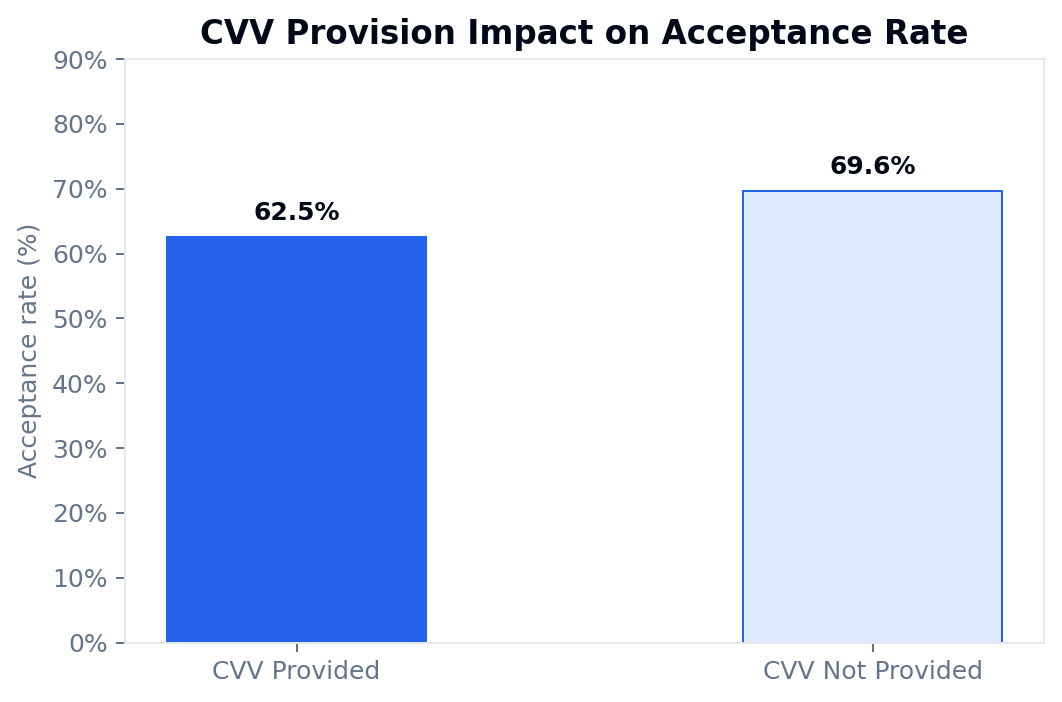

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = [BRAND_BLUE, SOFT_SKY]
bars = ax.bar(df_cvv['label'], df_cvv['acceptance_rate_pct'],
              color=colors, width=0.45, edgecolor=BRAND_BLUE, linewidth=0.8)
ax.bar_label(bars, fmt='%.1f%%', padding=5, color=DEEP_NAVY, fontweight='semibold')
ax.set_ylabel('Acceptance rate (%)')
ax.set_title('CVV Provision Impact on Acceptance Rate')
ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_04_cvv_acceptance_impact.png')
plt.show()

**Transactions without CVV show a higher acceptance rate (69.6%) than those with CVV (62.5%).** This is counterintuitive — CVV transactions are rare (40 vs 5,390), suggesting they may represent a specific payment flow with lower baseline acceptance rather than CVV causing declines. Recommendation: investigate whether CVV-flagged transactions share other characteristics (country, source, amount range) before drawing conclusions.